In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [18]:
df = pd.read_csv("../data/processed/cleaned_tickets.csv")

In [23]:
model = LogisticRegression(max_iter=1000)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

In [20]:
X = vectorizer.transform(df['cleaned_text'])

In [21]:
y = df['Ticket Type']

In [27]:
y_pred = model.predict(X_test)

In [29]:
cm = confusion_matrix(y_test, y_pred)

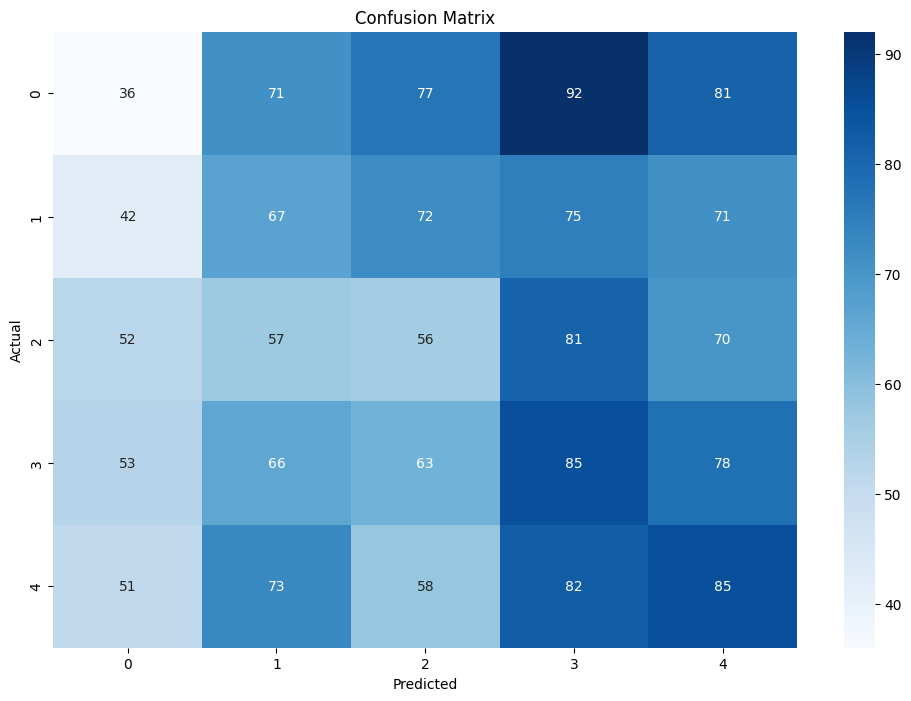

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [33]:
report = classification_report(y_test, y_pred)

print(report)

                      precision    recall  f1-score   support

     Billing inquiry       0.15      0.10      0.12       357
Cancellation request       0.20      0.20      0.20       327
     Product inquiry       0.17      0.18      0.17       316
      Refund request       0.20      0.25      0.22       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



In [34]:
with open("../outputs/classification_report.txt", "w") as f:
    f.write(report)